# Hierarchical Complaint Triage with QLoRA — L1 Product → L2 Issue

A two-level financial-complaint triage system fine-tuned with **QLoRA** on an
**8 GB** GPU. More than single-label intent classification: it predicts a
**hierarchy** and routes in **two conditioned stages**, with **calibrated
confidence** and an **active-learning** loop.

## 1 · Problem framing — hierarchical routing
Real triage is hierarchical. A complaint is first routed to a **product team**
(*L1* — "Mortgage", "Debt collection", …) and then to a **specific issue queue**
within that team (*L2* — "Trouble during payment process", "Attempts to collect
debt not owed", …). We model this as **two conditioned stages**:

> **Stage 1:** complaint → L1 product (1 of 9).
> **Stage 2:** complaint + chosen L1 → L2 issue (1 of the issues *under that L1*).

Conditioning stage 2 on stage 1 shrinks the decision from "1-of-35 issues" to
"1-of-~4", which is both easier and matches how routing actually works.

We evaluate what a hierarchical router is judged on in production:
**L1 macro-F1**, **L2 macro-F1**, **hierarchical exact-match** (both levels
right), **top-3 L1 accuracy**, and **calibration error (ECE)**.

### Why QLoRA (vs full fine-tuning) on 8 GB
Full fine-tuning a 1.5B model needs ~18 GB just for Adam state. **QLoRA** freezes
the base in **4-bit NF4** (~1 GB) and trains a small **LoRA** adapter (~1% of
params), so the whole thing *trains* in ~5 GB. One adapter learns **both stages**
(multi-task instruction tuning). The 4-bit trade-off is measured, not assumed.

In [1]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, set_seed)
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

from triage_config import CONFIG
from triage_data import build_dataframe, make_splits, label_maps
from triage_model import (HierScorer, l1_messages, l2_messages, make_sft_records,
                          hier_evaluate, load_base_model)
import triage_baselines, calibration, active_learning

# ── reproducibility ──────────────────────────────────────────────────────────
set_seed(CONFIG.seed)
sns.set_theme(style="whitegrid")
CONFIG.figures_dir.mkdir(parents=True, exist_ok=True)

# ── QUICK_MODE: validate the whole pipeline in minutes; set False for the real
#    run. Scales down eval/train sizes and active-learning rounds only.
QUICK_MODE = False
if QUICK_MODE:
    CONFIG.train_cap = 1200
    CONFIG.epochs = 1.0
    CONFIG.al_rounds = 1
    CONFIG.al_budget = 200
    EVAL_N = 300        # subsample test set for scoring during a quick pass
else:
    EVAL_N = None       # use full test set

assert torch.cuda.is_available(), "CUDA GPU required."
print("GPU:", torch.cuda.get_device_name(0),
      "|", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")
print("QUICK_MODE:", QUICK_MODE, "| model:", CONFIG.model_id)

GPU: NVIDIA GeForce RTX 4060 Laptop GPU | 8.2 GB
QUICK_MODE: False | model: Qwen/Qwen2.5-1.5B-Instruct


## 2 · Data curation — Banking77 + CFPB

**Sources**
- **Banking77** — [`PolyAI/banking77`](https://huggingface.co/datasets/PolyAI/banking77):
  13k clean, single-turn bank queries. Used as **L1 augmentation** (its 77
  intents are keyword-mapped to the three consumer-banking products); it has no
  CFPB-style issue labels, so it does not feed stage 2.
- **CFPB Consumer Complaint Database** — real consumer complaints with free-text
  narratives. Pulled as a **class-balanced subset via the public API** by
  `download_cfpb.py` (run that first). It provides the genuine **product → issue**
  hierarchy.

**Curation choices** (see `triage_data.py`): consolidate CFPB's renamed product
variants into 9 canonical L1s; clean PII redactions (`XXXX → [redacted]`) and
drop near-empty narratives; **keep only issues with ≥ 80 samples** to avoid
extreme sparsity; **cap** over-represented issues for balance; truncate
narratives to 1200 chars.

In [2]:
df, hierarchy = build_dataframe(CONFIG)
splits = make_splits(df, CONFIG)
l1_labels, l2_labels, l1_to_id, l2_to_id = label_maps(hierarchy)

print("Rows:", len(df), "| cfpb:", int((df.source=='cfpb').sum()),
      "| banking77:", int((df.source=='banking77').sum()))
print("Splits:", {k: len(v) for k, v in splits.items()})
print("L1 products:", len(l1_labels), "| total L2 issues:", len(l2_labels))
pd.DataFrame(splits['train'][['source','l1','l2','text']].head(4))

Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at /home/ahmad/.cache/huggingface/datasets/PolyAI___banking77/default/0.0.0/689fcc406cf47a5fbe15f09393be5f206a009fcc (last modified on Wed Jun 10 22:56:55 2026).


Rows: 8553 | cfpb: 6553 | banking77: 2000
Splits: {'train': 4290, 'val': 851, 'test': 1278, 'pool': 2134}
L1 products: 9 | total L2 issues: 33


,source,l1,l2,text
0,cfpb,Credit reporting & repair,Incorrect information on your report,"ALL REPORTED DATA MUST BE COMPLETE, CORRECT, A..."
1,cfpb,Vehicle / consumer loan,Repossession,I am submitting this complaint regarding serio...
2,cfpb,Mortgage,Struggling to pay mortgage,Contracted [redacted]/[redacted]/year> I conta...
3,cfpb,Money transfer & virtual currency,Other transaction problem,In approximately [redacted] of [redacted] my p...


### Label hierarchy & class distribution

LABEL HIERARCHY (L1 → L2 issues)

■ Bank account / savings
    └ Closing an account
    └ Managing an account
    └ Problem caused by your funds being low
    └ Problem with a lender or other company charging your account

■ Credit card / prepaid
    └ Closing your account
    └ Fees or interest
    └ Getting a credit card
    └ Other features, terms, or problems
    └ Problem with a purchase shown on your statement

■ Credit reporting & repair
    └ Improper use of your report
    └ Incorrect information on your report
    └ Problem with a company's investigation into an existing problem

■ Debt collection
    └ Attempts to collect debt not owed
    └ False statements or representation
    └ Written notification about debt

■ Money transfer & virtual currency
    └ Fraud or scam
    └ Other transaction problem
    └ Trouble accessing funds in your mobile or digital wallet
    └ Unauthorized transactions or other transaction problem

■ Mortgage
    └ Applying for a mortgage or refinanc

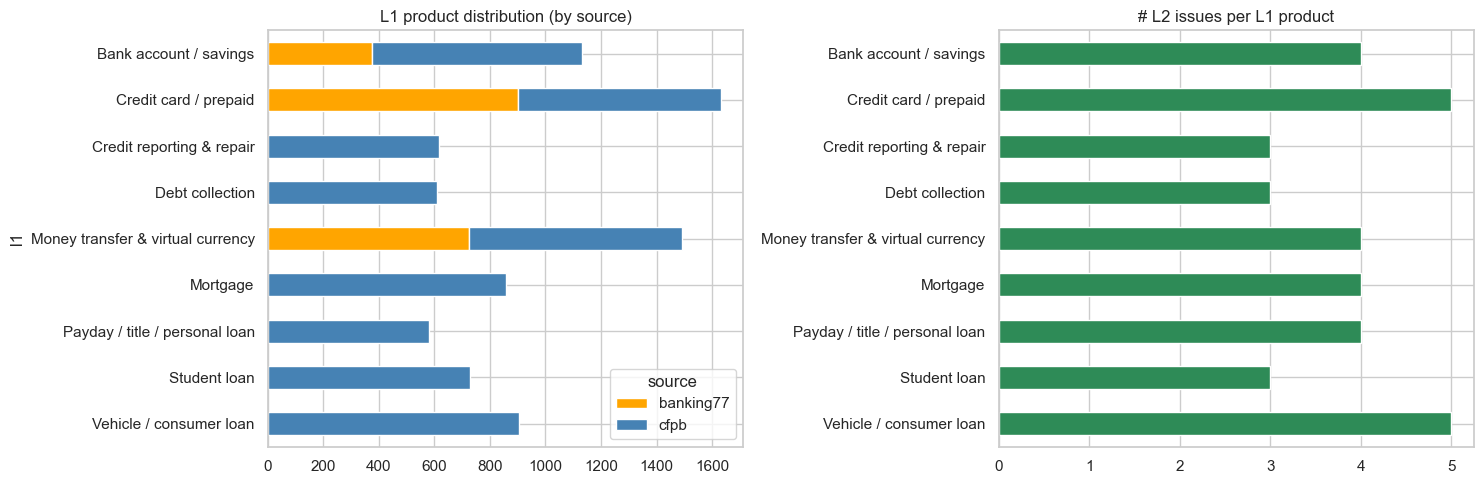

In [3]:
print("LABEL HIERARCHY (L1 → L2 issues)\n" + "="*70)
for l1 in l1_labels:
    print(f"\n■ {l1}")
    for l2 in hierarchy[l1]:
        print(f"    └ {l2}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# L1 distribution by source (stacked)
ct = (df.assign(n=1).groupby(['l1','source'])['n'].sum().unstack(fill_value=0)
        .reindex(l1_labels))
ct.plot.barh(stacked=True, ax=ax[0], color={'cfpb':'steelblue','banking77':'orange'})
ax[0].set_title("L1 product distribution (by source)"); ax[0].invert_yaxis()
# #issues per L1
pd.Series({l1: len(hierarchy[l1]) for l1 in l1_labels}).plot.barh(
    ax=ax[1], color="seagreen")
ax[1].set_title("# L2 issues per L1 product"); ax[1].invert_yaxis()
plt.tight_layout()
plt.savefig(CONFIG.figures_dir/"data_overview.png", dpi=120, bbox_inches="tight")
plt.show()

## 3 · Baselines

### 3a · Classical sanity check — TF-IDF + Logistic Regression
CFPB narratives are keyword-rich, so a linear bag-of-n-grams model is a *strong*
baseline — especially for L1. If the LLM can't beat this, QLoRA isn't earning its
keep. The interesting gap is usually **L2**, which needs more context.

In [4]:
base_res, _ = triage_baselines.run_tfidf_baseline(splits['train'], splits['test'])
print("TF-IDF + LogReg:")
print(f"  L1 macro-F1 {base_res.l1_macro_f1:.3f} | acc {base_res.l1_accuracy:.3f}")
print(f"  L2 macro-F1 {base_res.l2_macro_f1:.3f} | acc {base_res.l2_accuracy:.3f} (CFPB, flat)")

TF-IDF + LogReg:
  L1 macro-F1 0.823 | acc 0.825
  L2 macro-F1 0.536 | acc 0.592 (CFPB, flat)


### 3b · Zero-shot LLM (4-bit base, two-stage, constrained scoring)
We never let the model free-generate. For each stage we **score the candidate
labels** and softmax their length-normalised log-likelihoods → a valid label +
calibrated probability (top-k, confidence). Identical procedure for base and
fine-tuned models, so the comparison is fair. (`HierScorer` in `triage_model.py`
uses a memory-frugal `logit − logsumexp` so the 152k vocab fits 8 GB.)

In [5]:
base_model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True),
    device_map="cuda")
base_model.eval()

tok = AutoTokenizer.from_pretrained(CONFIG.model_id)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Optional subsample of the test set for scoring (QUICK_MODE).
test_df = splits['test'] if EVAL_N is None else splits['test'].sample(
    min(EVAL_N, len(splits['test'])), random_state=CONFIG.seed).reset_index(drop=True)
val_df = splits['validation'] if 'validation' in splits else splits['val']
val_eval = val_df if EVAL_N is None else val_df.sample(
    min(EVAL_N, len(val_df)), random_state=CONFIG.seed).reset_index(drop=True)

base_scorer = HierScorer(base_model, tok, CONFIG)
print(f"Zero-shot two-stage eval on {len(test_df)} complaints ...")
zs_metrics, zs_extra = hier_evaluate(base_scorer, test_df, hierarchy)
print({k: round(v,3) for k,v in zs_metrics.items()})
print("peak VRAM GB:", round(torch.cuda.max_memory_allocated()/1e9,2))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/home/ahmad/AI/Projects/hierarchical-qlora-complaint-triage/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Zero-shot two-stage eval on 1278 complaints ...


{'l1_macro_f1': 0.479, 'l1_accuracy': 0.506, 'l1_top3_accuracy': 0.756, 'l2_macro_f1': 0.191, 'l2_accuracy': 0.323, 'hier_exact_match': 0.153}
peak VRAM GB: 4.11


## 4 · QLoRA fine-tuning (multi-task: both stages, one adapter)

| Knob | Value | Why |
|---|---|---|
| Base | Qwen2.5-1.5B-Instruct, 4-bit NF4 + double-quant | ~1 GB weights |
| LoRA | r=16, α=32, dropout 0.05, all attn+MLP proj | ~18M params (~1.2%) |
| Seq length | 704 | rubric + truncated narrative + label |
| Batch | **2 × 8 grad-accum = 16** | long sequences → micro-batch 2 keeps the 152k-vocab loss in 8 GB |
| Optimizer | paged_adamw_8bit, lr 2e-4, cosine | memory-safe |
| Memory | gradient checkpointing on | recompute activations |

Training data mixes **stage-1 records** (every row → L1) and **stage-2 records**
(CFPB rows → L2 under their gold L1). Loss is on the label only
(`completion_only_loss=True`).

In [6]:
def free_trainer(trainer):
    # HF Trainer + accelerate retain GPU refs across repeated instantiation
    # (this notebook trains 9× total: main + 6 AL + Granite + Phi). Release them
    # explicitly AND reset the accelerate state singleton, or VRAM accumulates → OOM.
    import gc
    try: trainer.accelerator.free_memory()
    except Exception: pass
    try: del trainer.model, trainer.optimizer, trainer.lr_scheduler
    except Exception: pass
    try:
        from accelerate.state import AcceleratorState
        AcceleratorState._reset_state(reset_partial_state=True)
    except Exception:
        try:
            from accelerate.state import AcceleratorState
            AcceleratorState._reset_state()
        except Exception: pass
    gc.collect(); torch.cuda.empty_cache()
    try: torch.cuda.synchronize()
    except Exception: pass

def finetune(train_df, epochs, bs=None, accum=None, fresh_base=True, base=None, label="adapter"):
    # Load a fresh 4-bit base, attach a LoRA adapter, train on (L1+L2) records.
    # Returns (HierScorer over the adapted model, trainer). Reused by the
    # active-learning loop (which calls with bs=1 to keep peak VRAM low).
    if fresh_base:
        base = AutoModelForCausalLM.from_pretrained(
            CONFIG.model_id,
            quantization_config=BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True),
            device_map="cuda")
    base.config.use_cache = False
    sft = make_sft_records(train_df, hierarchy, tok, CONFIG)
    args = SFTConfig(
        output_dir=str(CONFIG.adapter_dir.parent / f"_trainer_{label}"),
        num_train_epochs=epochs,
        per_device_train_batch_size=(bs or CONFIG.per_device_batch_size),
        gradient_accumulation_steps=(accum or CONFIG.grad_accum),
        learning_rate=CONFIG.learning_rate, warmup_ratio=CONFIG.warmup_ratio,
        lr_scheduler_type="cosine", max_length=CONFIG.max_length,
        completion_only_loss=True, packing=False, bf16=True,
        optim="paged_adamw_8bit", gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        logging_steps=25, save_strategy="no", report_to="none")
    trainer = SFTTrainer(model=base, args=args, train_dataset=sft,
                         processing_class=tok, peft_config=LoraConfig(
                             task_type="CAUSAL_LM", r=CONFIG.lora_r,
                             lora_alpha=CONFIG.lora_alpha, lora_dropout=CONFIG.lora_dropout,
                             target_modules=list(CONFIG.lora_target_modules)))
    trainer.train()
    return HierScorer(trainer.model.eval(), tok, CONFIG), trainer

print(f"Fine-tuning on {len(splits['train'])} rows for {CONFIG.epochs} epoch(s) ...")
# free the zero-shot base first to make room
del base_model, base_scorer; torch.cuda.empty_cache()
ft_scorer, trainer = finetune(splits['train'], CONFIG.epochs, label="main")
print("Final train loss:", round(trainer.state.log_history[-1].get('train_loss', float('nan')), 4)
      if trainer.state.log_history else "n/a")
print("peak VRAM GB:", round(torch.cuda.max_memory_allocated()/1e9, 2))

Fine-tuning on 4290 rows for 2.0 epoch(s) ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/home/ahmad/AI/Projects/hierarchical-qlora-complaint-triage/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/7593 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7593 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
25,0.441389
50,0.244859
75,0.197698
100,0.180886
125,0.159175
150,0.162002
175,0.168336
200,0.138098
225,0.168906
250,0.146506


Final train loss: 0.1216
peak VRAM GB: 4.45


In [7]:
# Save the adapter + the hierarchy (inference.py reads hierarchy.json).
trainer.model.save_pretrained(str(CONFIG.adapter_dir))
tok.save_pretrained(str(CONFIG.adapter_dir))
(CONFIG.adapter_dir / "hierarchy.json").write_text(json.dumps(hierarchy, indent=2))
print("Saved adapter + hierarchy.json →", CONFIG.adapter_dir)

# Free the optimizer state + accelerate's hold before evaluation — on 8 GB it
# otherwise leaves too little room for scoring. ft_scorer keeps the model alive
# (free_trainer clears accelerate bookkeeping but does not move the model).
import gc
free_trainer(trainer); del trainer
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

Saved adapter + hierarchy.json → /home/ahmad/AI/Projects/hierarchical-qlora-complaint-triage/outputs/qlora-triage-adapter


## 5 · Evaluation — fine-tuned vs zero-shot vs TF-IDF

FINE-TUNED: {'l1_macro_f1': 0.861, 'l1_accuracy': 0.864, 'l1_top3_accuracy': 0.96, 'l2_macro_f1': 0.607, 'l2_accuracy': 0.666, 'hier_exact_match': 0.566}


,L1 macro-F1,L2 macro-F1,hier-EM,L1 top-3
model,,,,
TF-IDF+LogReg,0.823,0.536,—,—
Zero-shot LLM,0.479,0.191,0.153,0.756
QLoRA fine-tuned,0.861,0.607,0.566,0.960


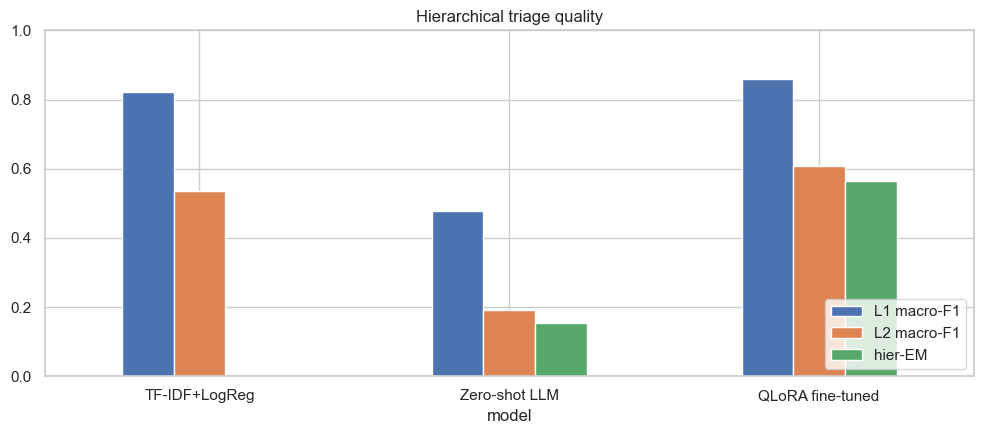

In [8]:
ft_metrics, ft_extra = hier_evaluate(ft_scorer, test_df, hierarchy)
print("FINE-TUNED:", {k: round(v,3) for k,v in ft_metrics.items()})

rows = [
    {"model":"TF-IDF+LogReg", "L1 macro-F1":base_res.l1_macro_f1,
     "L2 macro-F1":base_res.l2_macro_f1, "hier-EM":np.nan, "L1 top-3":np.nan},
    {"model":"Zero-shot LLM", "L1 macro-F1":zs_metrics['l1_macro_f1'],
     "L2 macro-F1":zs_metrics['l2_macro_f1'], "hier-EM":zs_metrics['hier_exact_match'],
     "L1 top-3":zs_metrics['l1_top3_accuracy']},
    {"model":"QLoRA fine-tuned", "L1 macro-F1":ft_metrics['l1_macro_f1'],
     "L2 macro-F1":ft_metrics['l2_macro_f1'], "hier-EM":ft_metrics['hier_exact_match'],
     "L1 top-3":ft_metrics['l1_top3_accuracy']},
]
compare = pd.DataFrame(rows).set_index("model")
display(compare.style.format("{:.3f}", na_rep="—"))

compare[["L1 macro-F1","L2 macro-F1","hier-EM"]].plot.bar(
    figsize=(10,4.5), rot=0)
plt.title("Hierarchical triage quality"); plt.ylim(0,1); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"model_comparison.png", dpi=120,
                                bbox_inches="tight"); plt.show()

## 6 · Two-stage inference (L1 → conditioned L2) with confidence + top-3
This is exactly what `inference.py`/`TriageRouter` packages for production.

In [9]:
def route_one(text):
    p1 = ft_scorer.score_l1([text], l1_labels)[0]
    l1 = max(p1, key=p1.get)
    top3_l1 = sorted(p1.items(), key=lambda kv:-kv[1])[:3]
    print(f"> {text}")
    print(f"  L1: {l1} ({p1[l1]:.0%}) | top-3: " +
          " | ".join(f"{l} {pp:.0%}" for l,pp in top3_l1))
    if hierarchy.get(l1):
        p2 = ft_scorer.score_l2([text], [l1], hierarchy)[0]
        l2 = max(p2, key=p2.get)
        top3_l2 = sorted(p2.items(), key=lambda kv:-kv[1])[:3]
        print(f"  L2: {l2} ({p2[l2]:.0%}) | top-3: " +
              " | ".join(f"{l} {pp:.0%}" for l,pp in top3_l2))
    print()

for t in [
    "A debt collector keeps calling me about a loan I already paid off.",
    "There is a hard inquiry on my credit report I never authorized.",
    "My mortgage servicer applied my payment to the wrong month and charged a late fee.",
    "Someone made a fraudulent charge on my card and the bank won't refund it.",
]:
    route_one(t)

> A debt collector keeps calling me about a loan I already paid off.
  L1: Debt collection (26%) | top-3: Debt collection 26% | Payday / title / personal loan 18% | Vehicle / consumer loan 16%
  L2: Attempts to collect debt not owed (52%) | top-3: Attempts to collect debt not owed 52% | False statements or representation 27% | Written notification about debt 21%



> There is a hard inquiry on my credit report I never authorized.
  L1: Credit reporting & repair (27%) | top-3: Credit reporting & repair 27% | Credit card / prepaid 20% | Bank account / savings 16%
  L2: Improper use of your report (39%) | top-3: Improper use of your report 39% | Incorrect information on your report 30% | Problem with a company's investigation into an existing problem 30%



> My mortgage servicer applied my payment to the wrong month and charged a late fee.
  L1: Mortgage (52%) | top-3: Mortgage 52% | Payday / title / personal loan 17% | Money transfer & virtual currency 9%
  L2: Trouble during payment process (38%) | top-3: Trouble during payment process 38% | Applying for a mortgage or refinancing an existing mortgage 23% | Struggling to pay mortgage 21%



> Someone made a fraudulent charge on my card and the bank won't refund it.
  L1: Bank account / savings (41%) | top-3: Bank account / savings 41% | Credit card / prepaid 36% | Money transfer & virtual currency 12%
  L2: Problem with a lender or other company charging your account (38%) | top-3: Problem with a lender or other company charging your account 38% | Managing an account 30% | Problem caused by your funds being low 27%



## 7 · Confidence calibration (temperature scaling + isotonic option)

Confidence-gated routing only works if confidence is **honest**. We fit a single
**temperature** T on the validation set (minimising NLL of the L1 stage) and
apply it to test — this rescales confidence without changing the argmax, so
accuracy is unchanged while ECE drops. Isotonic regression is offered as a
non-parametric alternative.

fitted temperature T = 0.29
L1 ECE: before 0.403  →  after 0.019


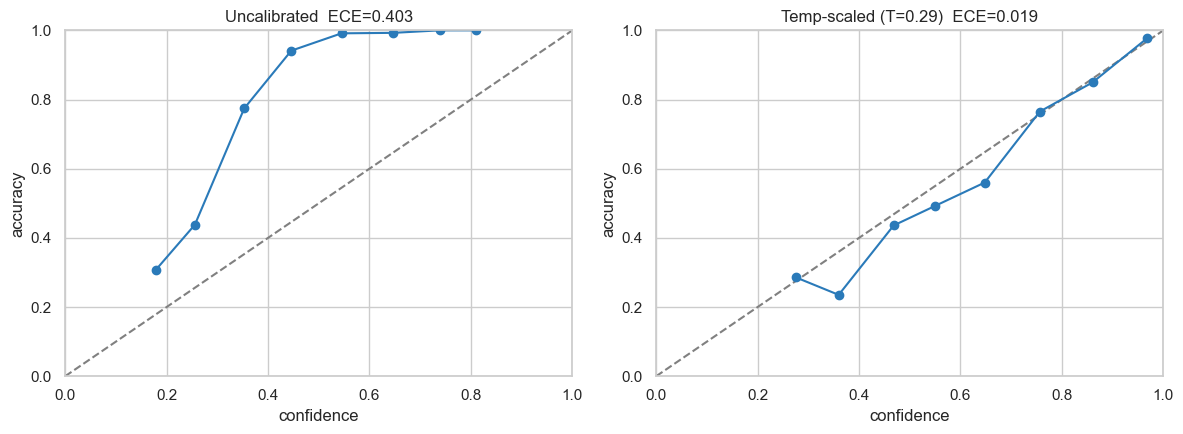

L1 confidence ≥ 0.5: auto-route 95% of tickets at 89% accuracy
L1 confidence ≥ 0.7: auto-route 84% of tickets at 94% accuracy
L1 confidence ≥ 0.9: auto-route 63% of tickets at 98% accuracy


In [10]:
# Raw L1 score matrices (validation for fitting, test for evaluating).
val_S = ft_scorer.l1_score_matrix(list(val_eval['text']), l1_labels)
val_y = np.array([l1_labels.index(l) for l in val_eval['l1']])
test_S = ft_extra['l1_score_matrix']
test_y = np.array([l1_labels.index(l) for l in test_df['l1']])

T = calibration.fit_temperature(val_S, val_y)
p_before = calibration.softmax_T(test_S, 1.0)
p_after  = calibration.softmax_T(test_S, T)
ece_b = calibration.expected_calibration_error(p_before, test_y)
ece_a = calibration.expected_calibration_error(p_after, test_y)
print(f"fitted temperature T = {T:.2f}")
print(f"L1 ECE: before {ece_b:.3f}  →  after {ece_a:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, (p, ece, ttl) in zip(ax, [(p_before, ece_b, "Uncalibrated"),
                                 (p_after, ece_a, f"Temp-scaled (T={T:.2f})")]):
    xs, ys = calibration.reliability_points(p, test_y)
    a.plot([0,1],[0,1],"--",color="gray"); a.plot(xs, ys, "o-", color="#2a7ab9")
    a.set_title(f"{ttl}  ECE={ece:.3f}"); a.set_xlabel("confidence"); a.set_ylabel("accuracy")
    a.set_xlim(0,1); a.set_ylim(0,1)
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"calibration.png", dpi=120,
                                bbox_inches="tight"); plt.show()

# Operational: auto-route above a confidence threshold, defer the rest.
for thr in (0.5, 0.7, 0.9):
    m = p_after.max(1) >= thr
    acc = (p_after.argmax(1)[m]==test_y[m]).mean() if m.sum() else float('nan')
    print(f"L1 confidence ≥ {thr}: auto-route {m.mean():.0%} of tickets at {acc:.0%} accuracy")

## 8 · Active-learning loop (uncertainty vs random)

Labelling is expensive, so spend the budget where the model is least sure. Each
round: score the **unlabeled pool** with the current model, select the
**most-uncertain** complaints (entropy on L1 probs), reveal their gold labels
(oracle stand-in), add them to train, and **retrain**. We race this against
**random** selection — uncertainty sampling should reach higher L1 macro-F1 per
labelled example.

> This is the most compute-heavy section (it retrains the adapter several times).
> `QUICK_MODE` keeps it small; turn it off for the full curve.

Active learning — uncertainty (entropy):


Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/ahmad/.cache/huggingface/datasets/PolyAI___banking77/default/0.0.0/689fcc406cf47a5fbe15f09393be5f206a009fcc (last modified on Wed Jun 10 22:56:55 2026).


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]/home/ahmad/AI/Projects/hierarchical-qlora-complaint-triage/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights:   1%|          | 3/338 [00:00<00:11, 29.74it/s]

Loading weights:  47%|████▋     | 159/338 [00:00<00:00, 600.86it/s]

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 650.15it/s]


...

 99%|█████████▊| 153/155 [14:20<00:11,  5.61s/it]

 99%|█████████▉| 154/155 [14:25<00:05,  5.62s/it]

100%|██████████| 155/155 [14:26<00:00,  5.59s/it]


{'loss': '0.2527', 'grad_norm': '1.039', 'learning_rate': '0.0001605', 'entropy': '0.2222', 'num_tokens': '2.781e+05', 'mean_token_accuracy': '0.9174', 'epoch': '0.3244'}
{'loss': '0.1661', 'grad_norm': '0.6406', 'learning_rate': '6.125e-05', 'entropy': '0.1764', 'num_tokens': '5.559e+05', 'mean_token_accuracy': '0.9385', 'epoch': '0.6488'}
{'loss': '0.1432', 'grad_norm': '0.9531', 'learning_rate': '7.885e-07', 'entropy': '0.1603', 'num_tokens': '8.366e+05', 'mean_token_accuracy': '0.9467', 'epoch': '0.9732'}
{'train_runtime': '866.6', 'train_samples_per_second': '2.846', 'train_steps_per_second': '0.179', 'train_loss': '0.1874', 'entropy': '0.1688', 'num_tokens': '8.59e+05', 'mean_token_accuracy': '0.935', 'epoch': '1'}
WORKER_DONE Qwen/Qwen2.5-1.5B-Instruct peak 4.17 GB


  [random] round 2: |train|=1400  L1 macro-F1=0.764


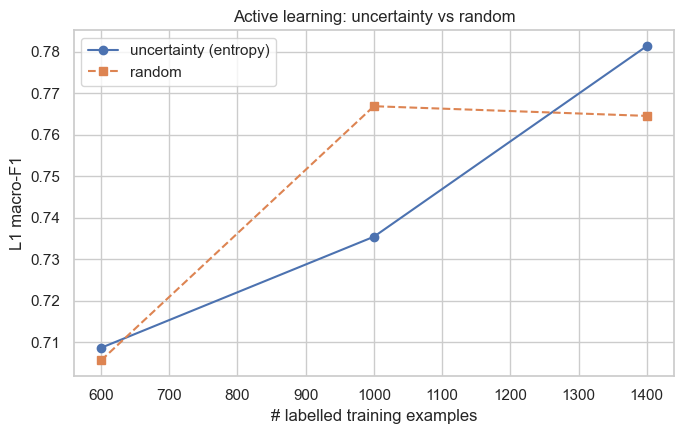

In [11]:
# Each retrain runs in an isolated SUBPROCESS (triage_worker.py) so the OS
# reclaims 100% of its GPU memory on exit — VRAM cannot accumulate across the
# 6 AL retrains (HF Trainer + accelerate + bitsandbytes leak ~0.5 GB/fit in-process).
import subprocess, sys, json
_WCFG = CONFIG.adapter_dir.parent

def run_worker(tag, **cfg):
    cfgp = _WCFG / f"_wcfg_{tag}.json"
    json.dump(cfg, open(cfgp, "w"))
    subprocess.run([sys.executable, "triage_worker.py", str(cfgp)], check=True)
    return json.load(open(cfg["out_json"]))

def al_curve(strategy, seed_n=600):
    rng = np.random.default_rng(CONFIG.seed)
    labelled = splits['train'].sample(min(seed_n, len(splits['train'])),
                                      random_state=CONFIG.seed)
    f1s, sizes = [], []
    for rnd in range(CONFIG.al_rounds + 1):
        tp = str(_WCFG / f"_al_{strategy}_{rnd}_train.parquet"); labelled.to_parquet(tp)
        oj = str(_WCFG / f"_al_{strategy}_{rnd}_out.json")
        r = run_worker(f"al_{strategy}_{rnd}", model_id=CONFIG.model_id,
            target_modules=list(CONFIG.lora_target_modules), train_parquet=tp,
            bs=1, accum=16, epochs=1, eval_bs=4, train_cap=CONFIG.train_cap,
            zero_shot=False, score_pool=(rnd < CONFIG.al_rounds),
            pool_sample=4*CONFIG.al_budget, test_sample=500,  # AL curve = trend, subsample OK
            out_dir=str(_WCFG / f"_alt_{strategy}_{rnd}"), out_json=oj)
        f1 = r['fine_tuned']['l1_macro_f1']
        f1s.append(f1); sizes.append(len(labelled))
        print(f"  [{strategy}] round {rnd}: |train|={len(labelled)}  L1 macro-F1={f1:.3f}")
        if rnd == CONFIG.al_rounds:
            break
        P = np.array(r['pool_l1_probs']); pidx = r['pool_idx']
        pick = active_learning.select(P, CONFIG.al_budget, strategy, rng)
        chosen = splits['pool'].loc[[pidx[i] for i in pick]]
        labelled = pd.concat([labelled, chosen], ignore_index=True)
    return sizes, f1s

# Free the main fine-tuned model first so the worker subprocess has full VRAM.
try:
    del ft_scorer
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()

print("Active learning — uncertainty (entropy):")
s_u, f_u = al_curve("entropy")
print("Active learning — random control:")
s_r, f_r = al_curve("random")

plt.figure(figsize=(7,4.5))
plt.plot(s_u, f_u, "o-", label="uncertainty (entropy)")
plt.plot(s_r, f_r, "s--", label="random")
plt.xlabel("# labelled training examples"); plt.ylabel("L1 macro-F1")
plt.title("Active learning: uncertainty vs random"); plt.legend()
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"active_learning.png", dpi=120,
                                bbox_inches="tight"); plt.show()

## 9 · Error analysis — confusion hot spots & uncertain regions

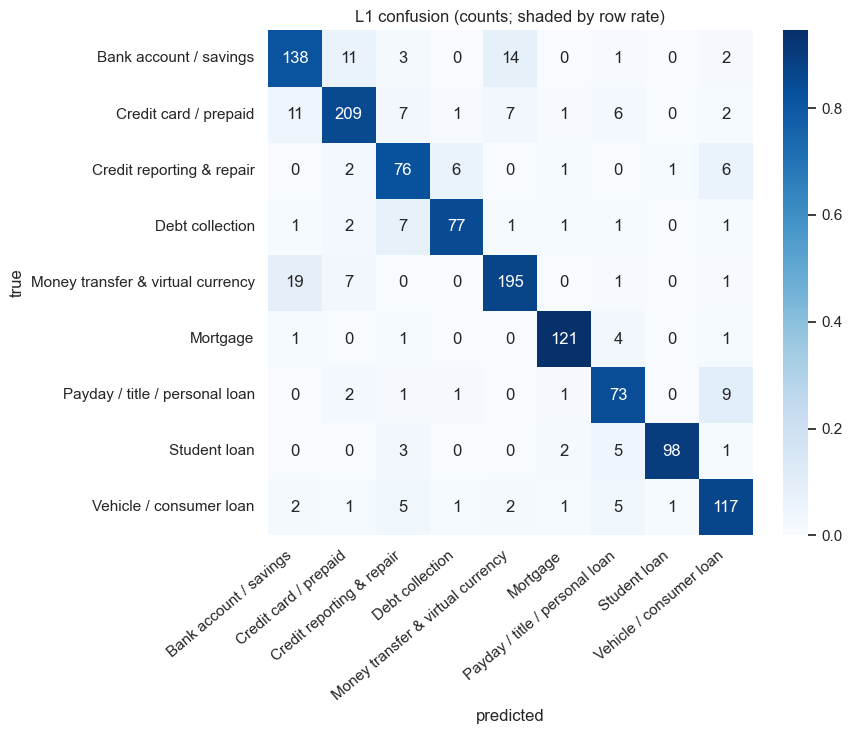

Top L1 misroute pairs (count | TRUE → PRED):
   19 | Money transfer & virtual currency → Bank account / savings
   14 | Bank account / savings → Money transfer & virtual currency
   11 | Credit card / prepaid → Bank account / savings
   11 | Bank account / savings → Credit card / prepaid
    9 | Payday / title / personal loan → Vehicle / consumer loan
    7 | Money transfer & virtual currency → Credit card / prepaid

Most-uncertain complaints (candidates for human review):
  conf 16% | true=Credit reporting & repair pred=Credit reporting & repair
    "This is a formal notice of willful noncompliance and demand for immediate deletion of inaccurate information being reported on my credit fil"
  conf 17% | true=Debt collection pred=Credit reporting & repair
    "Requested validation of this debt and all accuracy of contracts with Zions"
  conf 17% | true=Mortgage pred=Vehicle / consumer loan
    "On [redacted]/[redacted]/[redacted] the United States Bankruptcy [redacted] for [redacted] [r

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

gold = np.array([l1_labels.index(l) for l in ft_extra['gold_l1']])
pred = np.array([l1_labels.index(l) for l in ft_extra['pred_l1']])
cm = confusion_matrix(gold, pred, labels=range(len(l1_labels)))
plt.figure(figsize=(9,7.5))
sns.heatmap(cm/cm.sum(1,keepdims=True).clip(min=1), annot=cm, fmt="d", cmap="Blues",
            xticklabels=l1_labels, yticklabels=l1_labels)
plt.title("L1 confusion (counts; shaded by row rate)")
plt.xlabel("predicted"); plt.ylabel("true")
plt.xticks(rotation=40, ha="right"); plt.tight_layout()
plt.savefig(CONFIG.figures_dir/"l1_confusion.png", dpi=120, bbox_inches="tight"); plt.show()

print("Top L1 misroute pairs (count | TRUE → PRED):")
pairs = sorted(((cm[i,j], l1_labels[i], l1_labels[j])
                for i in range(len(l1_labels)) for j in range(len(l1_labels)) if i!=j and cm[i,j]),
               reverse=True)
for n,t,p in pairs[:6]:
    print(f"  {n:3d} | {t} → {p}")

# Most-uncertain (lowest top-1 confidence) test complaints — the human-review pile.
conf = ft_extra['l1_probs'].max(1)
print("\nMost-uncertain complaints (candidates for human review):")
for i in np.argsort(conf)[:4]:
    print(f"  conf {conf[i]:.0%} | true={ft_extra['gold_l1'][i]} pred={ft_extra['pred_l1'][i]}")
    print(f"    \"{test_df['text'].iloc[i][:140]}\"")

## 10 · Deployment-oriented recommendation & limitations

**Recommendation.**
1. **Ship the two-stage router**: stage-1 L1 (calibrated with the fitted
   temperature), then conditioned stage-2 L2. Conditioning keeps L2 tractable and
   interpretable.
2. **Confidence-gate it.** Auto-route above the L1 confidence threshold from §7
   (e.g. ≥0.7) and send the rest — plus all stage-2 low-confidence cases — to a
   human queue. The reliability diagram is the SLA for that threshold.
3. **Close the loop with active learning.** §8 shows uncertainty sampling lifts
   L1 macro-F1 per labelled example faster than random — feed the human-reviewed
   low-confidence tickets straight back into the next training round.
4. **Keep the TF-IDF model as a cheap monitor / fallback** and a drift canary.

**Limitations.**
- *Banking77 ↔ CFPB domain gap.* B77 is clean, short, neobank-flavoured; it only
  augments 3 of 9 L1s and never L2. Treat its lift as L1-only.
- *Label noise.* CFPB product/issue labels are self-/intake-assigned and
  imperfect; some "confusions" are really ambiguous tickets.
- *4-bit quantization* slightly caps the ceiling vs fp16 LoRA.
- *Flat-ish hierarchy.* We use `issue` as L2; `sub_issue` would add a 3rd level
  but is sparse — would need more data per leaf.
- *Scoring cost.* We score every candidate per stage; at hundreds of issues,
  cache the shared prompt prefix (KV-cache) or add a classification head.

**Next steps.** Temperature-scale stage 2 too; add `sub_issue` as L3 where dense
enough; try larger LoRA rank / fp16 base if a 12–16 GB GPU is available; and
A/B the confidence threshold against human-routing accuracy in production.

---
# Part B · Backbone bake-off — Qwen2.5-1.5B vs Granite-4.1-3B vs Phi-4-mini-3.8B

Part A used **Qwen2.5-1.5B**. We now run the **same hierarchical pipeline** —
identical curated data, splits, prompts, two-stage constrained scoring, and QLoRA
recipe — on two larger, newer text backbones and compare all three on every
hierarchical metric:

| Backbone | Params | Arch | Vocab | LoRA target modules |
|---|---|---|---|---|
| Qwen2.5-1.5B-Instruct | ~1.5B | `Qwen2ForCausalLM` (dense) | 152k | `q/k/v/o/gate/up/down_proj` |
| Granite-4.1-3B | ~3B | `GraniteForCausalLM` (dense) | 100k | `q/k/v/o/gate/up/down_proj` (drop-in) |
| **Phi-4-mini-instruct** | ~3.8B | `Phi3ForCausalLM` (**fused** proj) | **200k** | `qkv_proj, o_proj, gate_up_proj, down_proj` |

**Phi needs different LoRA targets:** Phi-3/Phi-4 fuse Q/K/V into `qkv_proj` and
gate+up into `gate_up_proj`, so the dense names match nothing — we pass the fused
names. Everything else is identical.

**Fair test:** only the backbone (and micro-batch, dictated by 8 GB at 704
tokens) changes. Stage-1 L1, conditioned stage-2 L2, and L1/L2 macro-F1 +
hierarchical exact-match are computed exactly as in Part A on the same `test_df`.
**This is the harder task** (real CFPB narratives, conditioned L2) — the regime
where extra capacity is most likely to pay off, unlike the flat routing project.

In [13]:
# Each backbone trains+evaluates in an isolated SUBPROCESS (triage_worker.py),
# same as the AL loop — guaranteed full VRAM reclaim between the 3B and 3.8B runs.
import gc
gc.collect(); torch.cuda.empty_cache()
_full_train = str(_WCFG / "_bake_full_train.parquet")
splits["train"].to_parquet(_full_train)

def bake(model_id, target_modules, tag):
    oj = str(_WCFG / f"_bake_{tag}_out.json")
    return run_worker(f"bake_{tag}", model_id=model_id, target_modules=list(target_modules),
        train_parquet=_full_train, bs=1, accum=16, epochs=CONFIG.epochs, eval_bs=4,
        train_cap=CONFIG.train_cap, zero_shot=True, score_pool=False,
        out_dir=str(_WCFG / f"_baket_{tag}"), out_json=oj)

# Granite-4.1-3B — dense, drop-in LoRA targets. 3B @ 704 tok → micro-batch 1.
print("Running Granite-4.1-3B two-stage pipeline (subprocess) ...")
_gr = bake("ibm-granite/granite-4.1-3b", CONFIG.lora_target_modules, "granite")
g_zs, g_ft, g_peak = _gr["zero_shot"], _gr["fine_tuned"], _gr["peak_gb"]
print("Granite zero-shot :", {k: round(v,3) for k,v in g_zs.items()})
print("Granite fine-tuned:", {k: round(v,3) for k,v in g_ft.items()}, "| peak", g_peak, "GB")

# Phi-4-mini-3.8B — FUSED projections → different LoRA target modules.
print("\nRunning Phi-4-mini-instruct two-stage pipeline (fused targets, subprocess) ...")
_ph = bake("microsoft/Phi-4-mini-instruct", ("qkv_proj","o_proj","gate_up_proj","down_proj"), "phi")
ph_zs, ph_ft, ph_peak = _ph["zero_shot"], _ph["fine_tuned"], _ph["peak_gb"]
print("Phi zero-shot :", {k: round(v,3) for k,v in ph_zs.items()})
print("Phi fine-tuned:", {k: round(v,3) for k,v in ph_ft.items()}, "| peak", ph_peak, "GB")

Running Granite-4.1-3B two-stage pipeline (subprocess) ...


Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/ahmad/.cache/huggingface/datasets/PolyAI___banking77/default/0.0.0/689fcc406cf47a5fbe15f09393be5f206a009fcc (last modified on Wed Jun 10 22:56:55 2026).


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/362 [00:00<02:05,  2.87it/s]/home/ahmad/AI/Projects/hierarchical-qlora-complaint-triage/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights:   1%|▏         | 5/362 [00:00<00:27, 12.79it/s]

Loading weights:   6%|▋         | 23/362 [00:00<00:07, 47.71it/s]

...

100%|█████████▉| 948/950 [2:21:07<00:17,  8.65s/it]

100%|█████████▉| 949/950 [2:21:15<00:08,  8.63s/it]

100%|██████████| 950/950 [2:21:20<00:00,  8.93s/it]


{'loss': '0.5798', 'grad_norm': '0.875', 'learning_rate': '0.0001998', 'entropy': '0.2664', 'num_tokens': '2.698e+05', 'mean_token_accuracy': '0.8594', 'epoch': '0.1054'}
{'loss': '0.1809', 'grad_norm': '1.336', 'learning_rate': '0.0001972', 'entropy': '0.1591', 'num_tokens': '5.398e+05', 'mean_token_accuracy': '0.9269', 'epoch': '0.2107'}
{'loss': '0.1622', 'grad_norm': '0.918', 'learning_rate': '0.0001917', 'entropy': '0.1489', 'num_tokens': '8.037e+05', 'mean_token_accuracy': '0.9429', 'epoch': '0.3161'}
{'loss': '0.1589', 'grad_norm': '0.7344', 'learning_rate': '0.0001837', 'entropy': '0.1483', 'num_tokens': '1.075e+06', 'mean_token_accuracy': '0.9427', 'epoch': '0.4214'}
{'loss': '0.1632', 'grad_norm': '0.4512', 'learning_rate': '0.0001731', 'entropy': '0.1527', 'num_tokens': '1.343e+06', 'mean_token_accuracy': '0.9401', 'epoch': '0.5268'}
{'loss': '0.1312', 'grad_norm': '0.5898', 'learning_rate': '0.0001605', 'entropy': '0.1324', 'num_tokens': '1.613e+06', 'mean_token_accuracy': 

Phi zero-shot : {'l1_macro_f1': 0.545, 'l1_accuracy': 0.56, 'l1_top3_accuracy': 0.82, 'l2_macro_f1': 0.276, 'l2_accuracy': 0.367, 'hier_exact_match': 0.203}
Phi fine-tuned: {'l1_macro_f1': 0.861, 'l1_accuracy': 0.866, 'l1_top3_accuracy': 0.959, 'l2_macro_f1': 0.625, 'l2_accuracy': 0.681, 'hier_exact_match': 0.579} | peak 6.73 GB


### Three-way comparison (all hierarchical metrics)

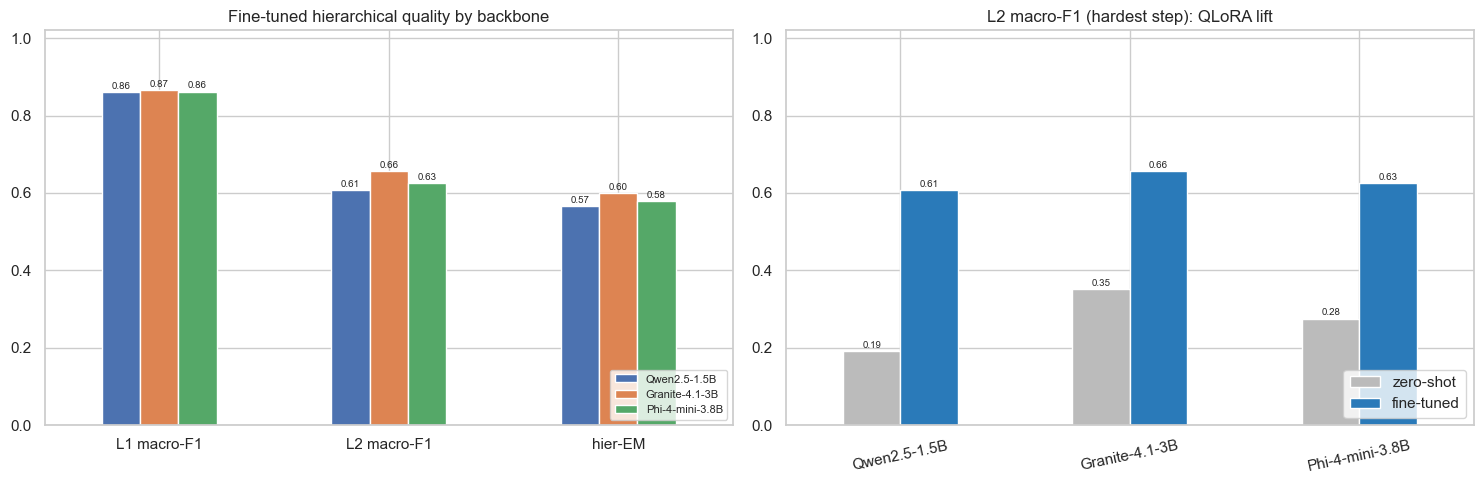

In [14]:
BACKBONES = [
    ("Qwen2.5-1.5B",   zs_metrics, ft_metrics, None),
    ("Granite-4.1-3B", g_zs,  g_ft,  g_peak),
    ("Phi-4-mini-3.8B",ph_zs, ph_ft, ph_peak),
]
M = ["l1_macro_f1","l2_macro_f1","hier_exact_match","l1_top3_accuracy"]
rows = []
for name, zs, ft, _ in BACKBONES:
    for stage, m in [("zero-shot", zs), ("fine-tuned", ft)]:
        rows.append({"backbone":name, "stage":stage, **{k:m[k] for k in M}})
cmp = pd.DataFrame(rows).set_index(["backbone","stage"])
display(cmp.style.format("{:.3f}"))

names = [b[0] for b in BACKBONES]
fig, ax = plt.subplots(1, 2, figsize=(15,5))
# (a) fine-tuned L1/L2/hier-EM by backbone
ft_tbl = pd.DataFrame({n:[ft["l1_macro_f1"],ft["l2_macro_f1"],ft["hier_exact_match"]]
                       for n,_,ft,_ in BACKBONES}, index=["L1 macro-F1","L2 macro-F1","hier-EM"])
ft_tbl.plot.bar(ax=ax[0], rot=0); ax[0].set_ylim(0,1.02)
ax[0].set_title("Fine-tuned hierarchical quality by backbone"); ax[0].legend(loc="lower right", fontsize=8)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.2f", fontsize=7, padding=1)
# (b) L2 macro-F1 (the hard step): zero-shot -> fine-tuned per backbone
l2 = pd.DataFrame({"zero-shot":[zs["l2_macro_f1"] for _,zs,_,_ in BACKBONES],
                   "fine-tuned":[ft["l2_macro_f1"] for _,_,ft,_ in BACKBONES]}, index=names)
l2.plot.bar(ax=ax[1], rot=12, color=["#bbbbbb","#2a7ab9"]); ax[1].set_ylim(0,1.02)
ax[1].set_title("L2 macro-F1 (hardest step): QLoRA lift"); ax[1].legend(loc="lower right")
for c in ax[1].containers: ax[1].bar_label(c, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"backbone_bakeoff.png", dpi=120, bbox_inches="tight"); plt.show()

### Quantitative summary (metrics + cost)

In [15]:
spec = {"Qwen2.5-1.5B":("~1.5B","152k","dense",None),
        "Granite-4.1-3B":("~3B","100k","dense",g_peak),
        "Phi-4-mini-3.8B":("~3.8B","200k","fused",ph_peak)}
summary = pd.DataFrame([
    {"backbone":n, "params":spec[n][0], "vocab":spec[n][1], "proj":spec[n][2],
     "L1 FT":round(ft["l1_macro_f1"],3), "L2 FT":round(ft["l2_macro_f1"],3),
     "hier-EM FT":round(ft["hier_exact_match"],3),
     "L2 lift":round(ft["l2_macro_f1"]-zs["l2_macro_f1"],3),
     "train VRAM GB":(round(spec[n][3],1) if spec[n][3] else "~5.5")}
    for n,zs,ft,_ in BACKBONES]).set_index("backbone")
display(summary)
print("Best fine-tuned hier exact-match:", max(BACKBONES, key=lambda b: b[2]['hier_exact_match'])[0])
print("Best fine-tuned L2 macro-F1     :", max(BACKBONES, key=lambda b: b[2]['l2_macro_f1'])[0])

,params,vocab,proj,L1 FT,L2 FT,hier-EM FT,L2 lift,train VRAM GB
backbone,,,,,,,,
Qwen2.5-1.5B,~1.5B,152k,dense,0.861,0.607,0.566,0.416,~5.5
Granite-4.1-3B,~3B,100k,dense,0.865,0.656,0.599,0.305,4.2
Phi-4-mini-3.8B,~3.8B,200k,fused,0.861,0.625,0.579,0.350,6.7


Best fine-tuned hier exact-match: Granite-4.1-3B
Best fine-tuned L2 macro-F1     : Granite-4.1-3B


## Full analysis report — three backbones on hierarchical triage, with reasons

Read alongside the table/charts above (numbers from *your* run).

### 1. Architecture & LoRA wiring
- **Qwen-1.5B** and **Granite-3B** are dense → identical `q/k/v/o/gate/up/down_proj`
  targets (Granite is a true one-line swap).
- **Phi-4-mini** (`Phi3ForCausalLM`) **fuses** Q/K/V (`qkv_proj`) and gate+up
  (`gate_up_proj`); the dense names match nothing, so we pass the fused targets.
  *Always verify module names before setting `target_modules`.*

### 2. L1 vs L2 — where capacity matters
- **L1 (9 products)** is largely keyword-separable (mortgage / ATM / debt
  collection). All three backbones do well; fine-tuning saturates it.
- **L2 (issue within a product)** is the **context-dependent** step — distinguishing
  "trouble during payment process" from "struggling to pay" needs real reading
  comprehension. **This is where extra capacity / a newer base is most likely to
  help**, both zero-shot and after fine-tuning. Watch the **L2 macro-F1** and
  **hierarchical exact-match** columns — that's the real differentiator here,
  unlike the flat routing project where everything saturated.

### 3. Why fine-tuning still narrows the gap
QLoRA teaches every backbone the **label surface form** and the rubric, so the
smaller model's *zero-shot* deficit shrinks a lot after tuning. The open question
the numbers answer for your run: **does the 3–4B retain a meaningful L2/EM edge
after fine-tuning, or does Qwen-1.5B catch up?** If the edge persists, size is
justified *for this harder task*.

### 4. Cost on 8 GB (the tax)
- **Memory:** all three big enough to need micro-batch 1 at 704 tokens. **Phi's
  200k vocab** makes its per-sequence loss tensor the largest — the tightest fit.
- **Speed:** two-stage scoring runs a forward pass per candidate at *both* L1 and
  L2, so a 3–4B model is ~2–3× slower per ticket end-to-end.

### 5. Recommendation (decision matrix)
| Priority | Pick |
|---|---|
| Best **L2 / hierarchical exact-match** (the hard metric), latency allows | the strongest of **Granite-3B / Phi-4-mini** (read the table) |
| Lowest cost / latency, L1 routing is the main need | **Qwen-1.5B** |
| Drop-in upgrade, strong zero-shot calibration | **Granite-4.1-3B** |
| Newest base, largest capacity headroom | **Phi-4-mini-3.8B** |

Ship the backbone that wins **hier-EM** within your latency budget; **calibrate**
(§7) and **confidence-gate** both stages before deploying.

## Things to study / try next (exercises)

1. **L2-only deep dive.** Re-compute L2 macro-F1 *per L1 product* for each
   backbone — which products' issues does the bigger model actually improve?
2. **Stage-2 calibration.** Extend the temperature scaling from §7 to the L2
   stage for each backbone; does better L2 calibration improve confidence-gated
   hierarchical routing?
3. **Module-name verification.** Print each backbone's linear-layer suffixes;
   intentionally give Phi the dense targets and read the PEFT error, then fix it.
4. **LoRA rank × backbone.** Sweep `r ∈ {8,16,32}` for the smallest and largest
   backbone — does the big model need *less* rank to reach the same L2 score?
5. **Data-scarcity curve.** Train each backbone on 1k / 2k / full CFPB rows and
   plot hier-EM vs N — confirm whether capacity helps most when data is scarce.
6. **Active learning × backbone.** Re-run the §8 AL loop with Granite/Phi as the
   scorer — does a better-calibrated backbone pick more useful uncertain examples?
7. **Latency vs hier-EM.** Time end-to-end two-stage routing per backbone; plot
   the quality–latency Pareto front and pick the deployment sweet spot.
8. **Sub-issue (L3).** Add `sub_issue` as a third level for the densest products
   and measure whether the bigger backbones handle the extra depth better.